# Decision Trees — Complete Notes

A complete walkthrough of Decision Tree classification with scikit-learn on the Iris dataset (3-class flower classification), followed by a full hyperparameter reference.

- **Part 1:** Decision Trees with Scikit-Learn (Iris Dataset)
- **Part 2:** Real-World Uses & Hyperparameter Tuning

---
# Part 0: The Theory Behind the Tree

Typed up from the handwritten notes (`Decision Tree.pdf`), with every formula verified in
running code rather than left on paper. Part 1 then applies all of it with scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

## 0.1 What Is a Decision Tree?

A **supervised** learning algorithm that works for both **classification** and **regression**. It is *non-parametric*: no equation is assumed in advance, and the model is a flowchart of nested if-else questions learned from the data.

Predicting is trivial — start at the top, answer one question per node, and read off the answer at the bottom:

```
                  [ petal length <= 2.45 ? ]        <- root node
                     /                \
                  yes                  no
                   /                     \
             ( setosa )        [ petal width <= 1.65 ? ]   <- decision node
              leaf node            /              \
                                yes                no
                                 /                  \
                        ( versicolor )         ( virginica )
                            leaf                    leaf
```

## 0.2 Anatomy and Terminology

| Term | Meaning |
|---|---|
| **Root node** | The top node, holding the entire training set before any split. |
| **Splitting** | Dividing a node into two child nodes using one `feature <= threshold` test. |
| **Decision (internal) node** | Any node that asks a question and splits further. |
| **Branch / sub-tree** | A section of the tree hanging off one node. |
| **Leaf (terminal) node** | A node that does not split; it carries the prediction (majority class, or mean value for regression). |
| **Parent / child** | The node above / below a given split. |
| **Depth** | The number of questions on the longest path from root to leaf. |
| **Pruning** | Removing branches — the reverse of splitting — to fight overfitting. |

**Prediction rule:** a classification leaf predicts the *majority class* of the training samples that landed in it; a regression leaf predicts their *mean*.

## 0.3 How Does the Tree Choose a Split?

The algorithm is **greedy, top-down and recursive** (this is *recursive binary splitting*):

1. At the current node, consider **every feature** and **every candidate threshold** for it.
2. Score each candidate split by how much it reduces **impurity** — "how mixed are the classes here?"
3. Keep the single best split, apply it, and repeat on both children.
4. Stop when the node is pure, or a stopping rule fires (`max_depth`, `min_samples_leaf`, ...).

A split's score is the **weighted** impurity of its two children — weighted, because a split that leaves 90% of the data in a still-messy node has not achieved much:

$$ I_{\text{split}} \;=\; \frac{n_{\text{left}}}{n} I(\text{left}) \;+\; \frac{n_{\text{right}}}{n} I(\text{right}) $$

Greedy means the best split *now*, not the best tree overall — finding the globally optimal tree is NP-complete, so every practical implementation takes the greedy route.

## 0.4 Impurity Measure 1 — Entropy

Entropy measures disorder in a node, in bits:

$$ H(S) \;=\; -\sum_{i=1}^{k} p_i \log_2 p_i $$

where $p_i$ is the proportion of class $i$ in node $S$.

- All one class ($p = 1$) → $H = 0$ — perfectly pure.
- Even 50/50 split in a binary node → $H = 1$ — maximally mixed.

In [2]:
def entropy(counts):
    counts = np.asarray(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log2(p)).sum()) + 0.0   # + 0.0 turns a -0.0 into 0.0

print("[10, 0]  all one class  -> H =", round(entropy([10, 0]), 4))
print("[9, 1]   nearly pure    -> H =", round(entropy([9, 1]), 4))
print("[5, 5]   50/50          -> H =", round(entropy([5, 5]), 4))
print("[5,5,5]  3 equal classes-> H =", round(entropy([5, 5, 5]), 4), " (log2(3))")

[10, 0]  all one class  -> H = 0.0
[9, 1]   nearly pure    -> H = 0.469
[5, 5]   50/50          -> H = 1.0
[5,5,5]  3 equal classes-> H = 1.585  (log2(3))


## 0.5 Impurity Measure 2 — Gini Impurity

The probability of misclassifying a randomly chosen sample if it were labelled by randomly drawing a class from the node's own distribution:

$$ G(S) \;=\; 1 - \sum_{i=1}^{k} p_i^{\,2} $$

- Pure node → $G = 0$, same as entropy.
- Binary 50/50 → $G = 0.5$ (entropy would say `1.0`) — the two measures are on different scales but have the same shape.
- Maximum for $k$ classes is $1 - 1/k$.

Gini is scikit-learn's default because it needs no logarithms, so it's cheaper to compute — and as Part 2 Section 4 shows empirically, the two almost never disagree about which split to take.

[10, 0]      entropy = 0.0000   gini = 0.0000
[9, 1]       entropy = 0.4690   gini = 0.1800
[7, 3]       entropy = 0.8813   gini = 0.4200
[5, 5]       entropy = 1.0000   gini = 0.5000
[5, 5, 5]    entropy = 1.5850   gini = 0.6667


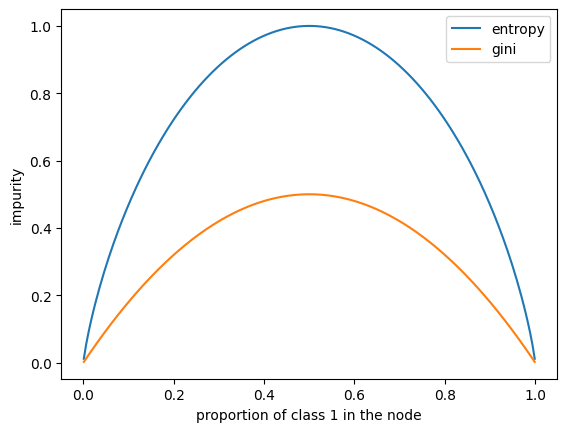

In [3]:
def gini(counts):
    counts = np.asarray(counts, dtype=float)
    p = counts / counts.sum()
    return float(1 - (p ** 2).sum())

for c in [[10, 0], [9, 1], [7, 3], [5, 5], [5, 5, 5]]:
    print(f"{str(c):<12} entropy = {entropy(c):.4f}   gini = {gini(c):.4f}")

# The two curves, side by side, for a binary node
ps = np.linspace(0.001, 0.999, 200)
plt.plot(ps, [-(p*np.log2(p) + (1-p)*np.log2(1-p)) for p in ps], label='entropy')
plt.plot(ps, [1 - (p**2 + (1-p)**2) for p in ps], label='gini')
plt.xlabel('proportion of class 1 in the node')
plt.ylabel('impurity')
plt.legend()
plt.show()

Same shape, same zeros at the pure ends, same peak in the middle — entropy simply runs on a taller scale. That is the whole practical difference between them.

## 0.6 Information Gain

**Information Gain** is how much impurity a split removes — parent impurity minus the weighted impurity of the children:

$$ IG \;=\; H(\text{parent}) - \left( \frac{n_{\text{left}}}{n} H(\text{left}) + \frac{n_{\text{right}}}{n} H(\text{right}) \right) $$

The tree picks the split with the **highest** information gain. (With `criterion='gini'` the identical formula is used with $G$ in place of $H$, and the result is usually called *Gini gain* or *impurity decrease* — it is what `min_impurity_decrease` thresholds in Part 2, Section 10.)

## 0.7 Worked Example — Doing It by Hand

The classic textbook table: should we play, given the weather? 14 rows, target `Play`.

In [4]:
play = pd.DataFrame({
    'Outlook':  ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                 'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':     ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
                 'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':     ['No','No','Yes','Yes','Yes','No','Yes',
                 'No','Yes','Yes','Yes','Yes','Yes','No']
})
play

,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes
5,Rain,Normal,Strong,No
6,Overcast,Normal,Strong,Yes
7,Sunny,High,Weak,No
8,Sunny,Normal,Weak,Yes
9,Rain,Normal,Weak,Yes


In [5]:
# Step 1 — entropy of the parent (the whole table)
parent_counts = play['Play'].value_counts()
print("Play counts:", {k: int(v) for k, v in parent_counts.items()})
H_parent = entropy(parent_counts.values)
print(f"H(parent) = {H_parent:.4f} bits")
print()

# Step 2 — information gain of every feature
n = len(play)
for feature in ['Outlook', 'Humidity', 'Wind']:
    weighted = 0.0
    parts = []
    for value, subset in play.groupby(feature):
        h = entropy(subset['Play'].value_counts().values)
        weighted += len(subset) / n * h
        parts.append(f"{value}({len(subset)}): H={h:.3f}")
    print(f"{feature:<9} -> " + "  ".join(parts))
    print(f"{'':<9}    weighted H = {weighted:.4f}   INFORMATION GAIN = {H_parent - weighted:.4f}")
    print()

Play counts: {'Yes': 9, 'No': 5}
H(parent) = 0.9403 bits

Outlook   -> Overcast(4): H=0.000  Rain(5): H=0.971  Sunny(5): H=0.971
             weighted H = 0.6935   INFORMATION GAIN = 0.2467

Humidity  -> High(7): H=0.985  Normal(7): H=0.592
             weighted H = 0.7885   INFORMATION GAIN = 0.1518

Wind      -> Strong(6): H=1.000  Weak(8): H=0.811
             weighted H = 0.8922   INFORMATION GAIN = 0.0481



**`Outlook` wins**, and the reason is visible in its own row: the `Overcast` branch has entropy `0.000` — every overcast day is a "Yes", so that branch becomes a leaf immediately and never needs another question. No other feature produces a pure child. This is exactly the calculation the tree performs at *every* node, for every feature and every threshold.

Now the same arithmetic, but checked against what scikit-learn actually computed for Part 1's Iris tree:

In [6]:
# A self-contained copy of the Part 1 setup, so this section runs on its own
iris = load_iris(as_frame=True).frame
X0, y0 = iris.drop(columns='target'), iris['target']
X0_tr, X0_te, y0_tr, y0_te = train_test_split(X0, y0, test_size=0.2, random_state=42, stratify=y0)
demo_tree = DecisionTreeClassifier(random_state=42).fit(X0_tr, y0_tr)

t = demo_tree.tree_
root, left, right = 0, t.children_left[0], t.children_right[0]

n_root, n_l, n_r = t.n_node_samples[root], t.n_node_samples[left], t.n_node_samples[right]
g_root, g_l, g_r = t.impurity[root], t.impurity[left], t.impurity[right]

print(f"root split : {X0.columns[t.feature[root]]} <= {t.threshold[root]:.2f}")
print(f"root       : n={n_root}  gini={g_root:.4f}   class counts = {t.value[root][0] * n_root}")
print(f"left child : n={n_l:<4} gini={g_l:.4f}")
print(f"right child: n={n_r:<4} gini={g_r:.4f}")
print()

weighted = (n_l / n_root) * g_l + (n_r / n_root) * g_r
print(f"weighted child impurity = {weighted:.4f}")
print(f"GINI GAIN               = {g_root - weighted:.4f}")
print()
print("hand-computed root gini :", round(gini(t.value[root][0] * n_root), 4))
print("sklearn's root gini     :", round(g_root, 4))

root split : petal length (cm) <= 2.45
root       : n=120  gini=0.6667   class counts = [40. 40. 40.]
left child : n=40   gini=0.0000
right child: n=80   gini=0.5000

weighted child impurity = 0.3333
GINI GAIN               = 0.3333

hand-computed root gini : 0.6667
sklearn's root gini     : 0.6667


The hand-written formula and the library agree exactly. Note how large that first gain is: one question about petal length removes most of the impurity in the dataset in a single step, which is why the setosa branch is pure immediately (`gini = 0.0`).

## 0.8 The Algorithm Families — ID3, C4.5, CART

The handwritten notes' entropy/information-gain formulation is the **ID3** tradition; scikit-learn implements **CART**. The differences are worth knowing because tutorials mix the names freely:

| | ID3 | C4.5 | CART (scikit-learn) |
|---|---|---|---|
| Split criterion | Information gain (entropy) | Gain ratio | Gini or entropy |
| Splits per node | One branch per category | One per category | **Always binary** |
| Feature types | Categorical only | Categorical + numeric | Numeric (encode categories yourself) |
| Regression? | No | No | **Yes** |
| Pruning | None | Error-based | Cost-complexity (`ccp_alpha`) |

Two practical consequences of scikit-learn being CART: every split is binary (`Outlook` above would become `Outlook == Overcast?`, not a three-way branch), and **categorical features must be encoded numerically yourself** — `DecisionTreeClassifier` will not accept raw strings.

## 0.9 Regression Trees

The same algorithm, with two substitutions:

| | Classification tree | Regression tree |
|---|---|---|
| Impurity | Gini / entropy | **MSE** (variance) or MAE |
| Leaf prediction | Majority class | **Mean** of the samples in the leaf |
| scikit-learn class | `DecisionTreeClassifier` | `DecisionTreeRegressor` |

Because a leaf predicts a single constant, a regression tree's output is a **step function**, never a smooth curve — it cannot extrapolate beyond the range of the training data at all.

## 0.10 Overfitting and Pruning

An unrestricted tree keeps splitting until every leaf is pure — which it can always achieve by isolating individual training rows. That is memorisation, not learning, and Part 1 Section 8 shows it happening.

| Strategy | When | How |
|---|---|---|
| **Pre-pruning** (early stopping) | *While* growing | `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, `min_impurity_decrease` |
| **Post-pruning** | *After* growing the full tree | `ccp_alpha` — cost-complexity pruning, which cuts back branches that don't pay for themselves |

Cost-complexity pruning scores a subtree $T$ as $R_\alpha(T) = R(T) + \alpha |T|$, where $R(T)$ is its error and $|T|$ its number of leaves. Larger $\alpha$ → leaves cost more → a smaller tree wins. Part 2, Section 9 sweeps $\alpha$ live.

## 0.11 Advantages and Disadvantages

| ✅ Advantages | ❌ Disadvantages |
|---|---|
| Easy to understand, and the fitted model can be *read* and drawn | Overfits badly if left unpruned |
| No feature scaling or normalisation needed | Unstable — small data changes can restructure the whole tree |
| Handles numeric and categorical (encoded) features | Greedy, so not guaranteed to be the optimal tree |
| Handles multi-class problems natively | Biased toward features with many distinct values |
| Fast at prediction time | Struggles with diagonal boundaries (splits are axis-aligned) |
| Non-linear relationships with no extra work | Poor at extrapolating in regression |
| Little data preparation; missing-value handling is possible | A single tree is usually beaten by an ensemble of them |

That last row is the bridge to Random Forest and gradient boosting — see Part 2, Section 7.

---
## Part 1: Decision Trees with Scikit-Learn (Iris Dataset)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


from sklearn.datasets import load_iris

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

from sklearn.model_selection import GridSearchCV

In [8]:
# extra imports used by the added sections
from sklearn.tree import plot_tree, export_text

## 1. Data Loading and Exploration

In [9]:
df = load_iris(as_frame=True).frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [10]:
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
129,7.2,3.0,5.8,1.6,2
74,6.4,2.9,4.3,1.3,1
114,5.8,2.8,5.1,2.4,2
67,5.8,2.7,4.1,1.0,1
39,5.1,3.4,1.5,0.2,0


In [11]:
df.shape

(150, 5)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [13]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


<Axes: xlabel='target', ylabel='count'>

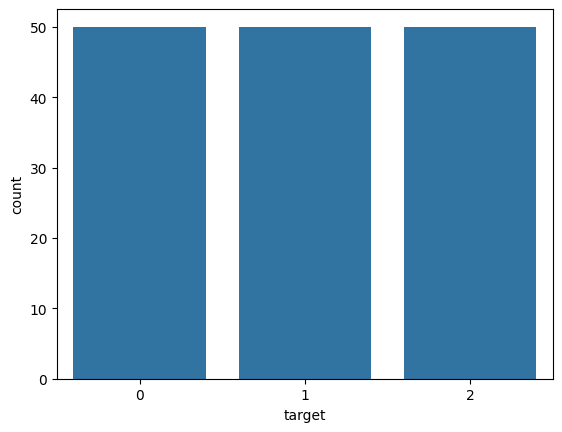

In [14]:
sns.countplot(data= df , x='target')

## 2. Train/Test Split

In [15]:
X = df.drop(['target'],axis=1)
y = df['target']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3
...,...,...,...,...
37,4.9,3.6,1.4,0.1
2,4.7,3.2,1.3,0.2
33,5.5,4.2,1.4,0.2
52,6.9,3.1,4.9,1.5


In [17]:
y_train.nunique()

3

## 3. Model Training

Unlike `KNeighborsClassifier`, a Decision Tree needs **no `StandardScaler` and no `Pipeline`**. It never measures a distance — it only ever asks "is this feature above or below some threshold?", and that question gives the same answer no matter what units the feature is in. This is one of the few models where skipping scaling is genuinely correct rather than lazy.

`random_state=42` is fixed here so the tree is reproducible: when two splits are equally good, the tree breaks the tie randomly.

In [18]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



That is the original model, fit with every default. One thing to fix before going further: with no `random_state`, ties between equally good splits are broken randomly, so re-running the cell can quietly give a different tree. Everything below re-fits with `random_state=42` so the numbers stay reproducible.

In [19]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## 4. Evaluation

In [20]:
y_pred = model.predict(X_test)
y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

In [21]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9333333333333333


In [22]:
conf_mat = confusion_matrix(y_test,y_pred)
conf_mat

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]])

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



`0.933` — 28 of 30 test flowers correct. The confusion matrix shows exactly where the two errors are: one *versicolor* predicted as *virginica* and one the other way round. Class `0` (*setosa*) is perfect, which is expected — it is linearly separable from the other two, while versicolor and virginica genuinely overlap.

Worth noting against the KNN notebook, which hit a perfect `1.00` on Wine: this is an unpruned tree grown to purity on the training set, and it still loses two test flowers. Sections 7-8 below deal with exactly that.

## 5. Looking Inside the Tree

This is what Decision Trees give you that almost no other model does: the fitted model can be **read directly**. Every prediction above is just a path down this diagram.

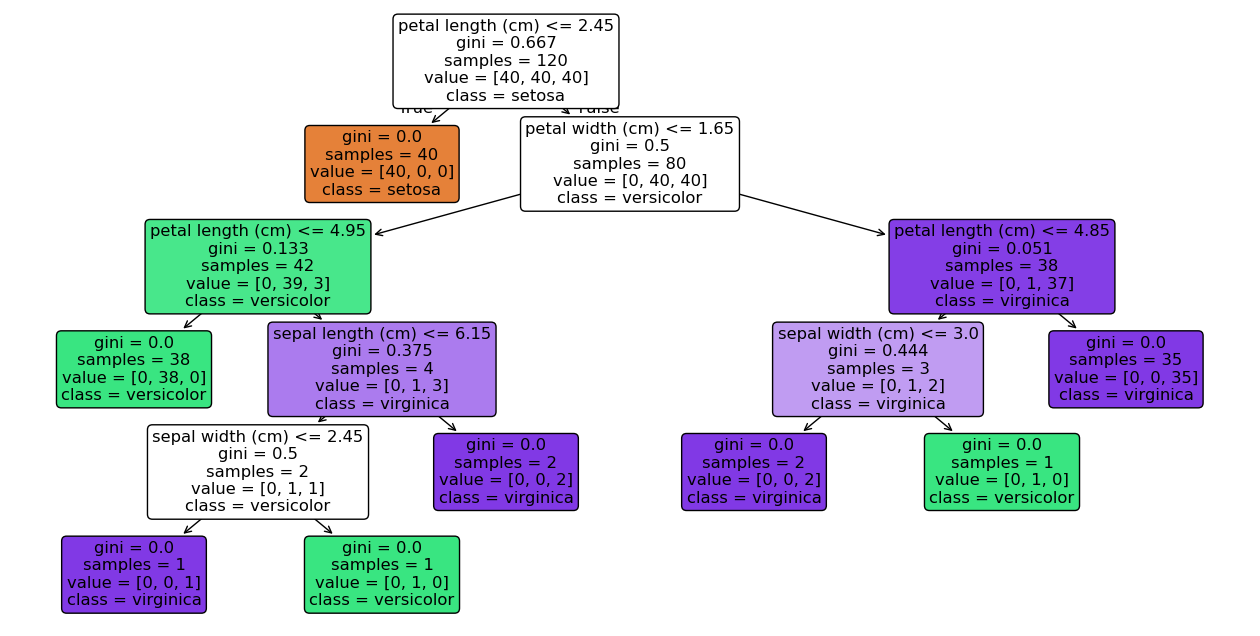

In [24]:
plt.figure(figsize=(16,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=load_iris().target_names,
    filled=True,
    rounded=True
)
plt.show()

In [25]:
print(export_text(model, feature_names=list(X.columns)))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- sepal length (cm) <= 6.15
|   |   |   |   |--- sepal width (cm) <= 2.45
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  2.45
|   |   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  6.15
|   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [26]:
print("depth   :", model.get_depth())
print("leaves  :", model.get_n_leaves())
print("nodes   :", model.tree_.node_count)

depth   : 5
leaves  : 8
nodes   : 15


Read the very first line of the text version: `petal length <= 2.45 → class 0`. One single comparison perfectly isolates all the setosas — no further questions asked. Everything below that root split is the tree trying to tease versicolor and virginica apart, and it needs 4 more levels and 8 leaves to do it, some of them on single flowers. Those deep, thin branches are the overfitting: `sepal width <= 2.45` at depth 4 is the tree memorising individual training rows, not learning a rule about irises.

## 6. Feature Importance

The tree also reports how much each feature contributed to reducing impurity across all its splits — a free, built-in feature-ranking that comes with no extra work.

petal length (cm)    0.558568
petal width (cm)     0.406015
sepal width (cm)     0.029167
sepal length (cm)    0.006250
dtype: float64


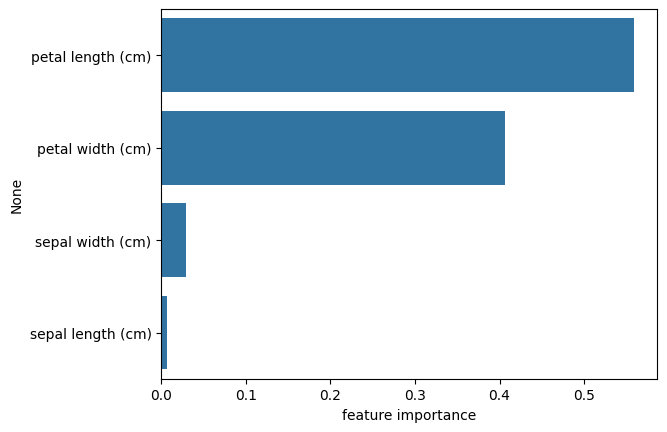

In [27]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

sns.barplot(x=importances.values, y=importances.index)
plt.xlabel("feature importance")
plt.show()

The two petal measurements carry about **96%** of the importance between them; sepal length contributes under 1%. That matches the tree diagram — petal length is the root split, and petal width is the split immediately after it. This kind of ranking usually costs a separate feature-selection step; here it falls out of the fitted model for free.

One caveat worth knowing: this is *impurity-based* importance, and it is known to inflate the score of high-cardinality (many-distinct-values) features. `sklearn.inspection.permutation_importance` is the more trustworthy alternative when the ranking really matters.

## 7. Hyperparameter Search with `GridSearchCV`

The tree above was grown with **all defaults**, which means it was allowed to grow until every leaf was pure — the classic recipe for overfitting. `GridSearchCV` tries every combination in the grid with 5-fold cross-validation on the *training* set, and keeps the best.

In [28]:
grid = {
    "criterion" : ['gini','entropy'],
    "max_depth" :[1,2,3,4,5,6,7,8,None],
}

grid_search = GridSearchCV(
    estimator = model,
    param_grid = grid,
    cv = 5
)

grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [29]:
print("best params :", grid_search.best_params_)
print("best cv score:", grid_search.best_score_)

best params : {'criterion': 'gini', 'max_depth': 4}
best cv score: 0.9416666666666668


In [30]:
y_pred = grid_search.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



The search settles on `criterion='gini'` with `max_depth=4`, at a cross-validated `0.942`. The test accuracy is `0.933` — **identical to the unpruned tree**, which is an honest and quite common outcome on a dataset this small and this easy: the grid found a smaller, simpler tree that performs just as well. Simpler at equal accuracy is a real win (it generalises more safely and is easier to read), but it is not the accuracy jump the grid search might have promised.

Note also that the grid only ever touched two of the thirteen available hyperparameters. Section 8 and all of Part 2 look at the rest.

## 8. Choosing `max_depth` — Accuracy Across Depths

The same idea as the KNN notebook's `k` sweep, but for the knob that matters most here. Sweeping `max_depth` from 1 to 15 and tracking **both** train and test accuracy, because the gap between the two is the whole story with trees.

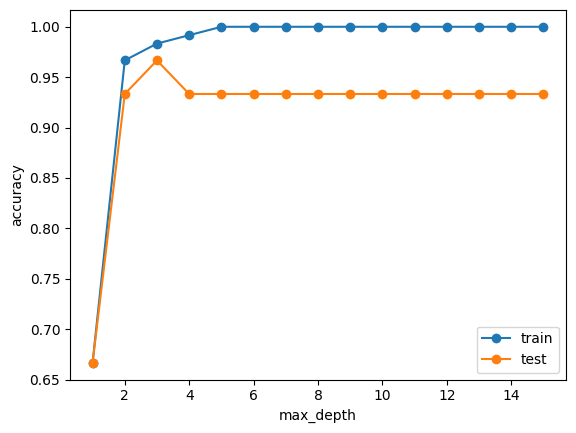

max_depth=1   train=0.667  test=0.667  gap=0.000
max_depth=2   train=0.967  test=0.933  gap=0.033
max_depth=3   train=0.983  test=0.967  gap=0.017
max_depth=4   train=0.992  test=0.933  gap=0.058
max_depth=5   train=1.000  test=0.933  gap=0.067
max_depth=6   train=1.000  test=0.933  gap=0.067
max_depth=7   train=1.000  test=0.933  gap=0.067
max_depth=8   train=1.000  test=0.933  gap=0.067
max_depth=9   train=1.000  test=0.933  gap=0.067
max_depth=10  train=1.000  test=0.933  gap=0.067
max_depth=11  train=1.000  test=0.933  gap=0.067
max_depth=12  train=1.000  test=0.933  gap=0.067
max_depth=13  train=1.000  test=0.933  gap=0.067
max_depth=14  train=1.000  test=0.933  gap=0.067
max_depth=15  train=1.000  test=0.933  gap=0.067


In [31]:
depths = range(1, 16)
train_acc = []
test_acc = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

plt.plot(depths, train_acc, marker='o', label='train')
plt.plot(depths, test_acc, marker='o', label='test')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.legend()
plt.show()

for d, tr, te in zip(depths, train_acc, test_acc):
    print(f"max_depth={d:<3} train={tr:.3f}  test={te:.3f}  gap={tr-te:.3f}")

The whole bias/variance story in one plot:

- **`max_depth=1`** — a single split ("decision stump"). It can only produce 2 leaves for 3 classes, so one class is unreachable and accuracy caps out at `0.667`. Textbook underfitting.
- **`max_depth=3`** — the sweet spot: `0.967` test, the highest anywhere in the sweep, with train at `0.983`. The gap is nearly closed.
- **`max_depth=5` and beyond** — train accuracy hits a perfect `1.000` while test **drops back** to `0.933`. The extra depth buys training accuracy only. That widening gap *is* overfitting, visible directly.
- **Past 5** — the curve is flat, because this tree naturally stops growing at depth 5 (every leaf is already pure). `max_depth=15` and `max_depth=None` are the same model here.

Compare with the KNN notebook's `k` sweep, where the direction is reversed: there, *small* `k` overfits and large `k` underfits. Here, small depth underfits and large depth overfits.

---
## Part 2: Real-World Uses & Hyperparameter Tuning

Where Decision Trees are used in practice, how they differ from KNN (a tree *does* learn something, unlike KNN's lazy storage), and a complete, tested reference for every hyperparameter `DecisionTreeClassifier` exposes — building directly on Part 1's Iris tree.

In [32]:
import time
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score

## 1. Where Are Decision Trees Used? (Real-World Applications)

Anywhere a decision has to be **explained**, not just made, a tree is a natural fit:

| Domain | Example |
|--------|---------|
| 🏦 Credit scoring | "Loan denied because income < X and existing debt > Y" — a regulator-friendly answer |
| 🏥 Clinical triage | Decision flowcharts doctors can read, audit, and disagree with |
| 📞 Churn prediction | Which customers are about to leave, and which rules identify them |
| 🏭 Manufacturing / fault diagnosis | Tracing a defect down a chain of yes/no sensor thresholds |
| 🎯 Marketing segmentation | Splitting an audience into interpretable buckets |
| 🌲 Building block for ensembles | Random Forest and Gradient Boosting are *hundreds of these trees* stacked together |
| 🌸 This notebook | Classifying an iris species from 4 flower measurements |

The last row is the big one in practice: a single tree is rarely the final production model, but it is the unit that **Random Forest, Extra Trees, XGBoost, LightGBM and CatBoost are all built out of**. Every hyperparameter in this notebook reappears inside those models.

## 2. Why Decision Trees? (and Their Trade-offs)

| Reason | Plain English |
|--------|---------------|
| **Fully interpretable** | You can print the whole model and read it (Section 5 of Part 1). Almost nothing else offers this. |
| **No scaling required** | Splits are threshold comparisons, not distances — the opposite of KNN's hard requirement. |
| **Handles mixed feature types** | Numeric and categorical-as-integer features live happily side by side. |
| **Non-linear by construction** | Carves the space into axis-aligned boxes; no assumption of a straight boundary like Logistic Regression. |
| **Naturally multi-class** | 3 iris species handled with no one-vs-rest wrapper. |
| **Fast predictions** | A prediction is a short walk down a tree — unlike KNN, which compares against the stored data every time. |
| **Trade-off: overfits by default** | Left unrestricted it will grow until every leaf is pure and memorise the training set. Pruning is not optional. |
| **Trade-off: unstable** | Change a few training rows and the tree can look completely different. This instability is exactly what Random Forest exploits and averages away. |
| **Trade-off: axis-aligned only** | A diagonal boundary has to be approximated with a staircase of splits. |

## 3. Parameters vs. Hyperparameters — Trees Sit Between KNN and Logistic Regression

The KNN notebook made the point that `.fit()` learns *nothing* — it just stores data. Logistic Regression sits at the other extreme: `.fit()` produces numbers (`coef_`, `intercept_`). A Decision Tree is a third case: `.fit()` learns a **structure**.

| | Logistic Regression ("eager", parametric) | KNN ("lazy") | Decision Tree ("eager", non-parametric) |
|---|---|---|---|
| What `.fit()` produces | Learned weights `coef_`, `intercept_` | Nothing — the stored data | A learned **tree**: which feature, which threshold, at every node |
| Fixed number of parameters? | Yes — one per feature | No parameters at all | No — the tree grows as large as the data allows |
| Prediction cost | One dot product | Compare against stored points | One walk down the tree (very fast) |

So a tree *does* have learned parameters — they just aren't a neat vector of numbers. They live in `model.tree_`:

In [33]:
print("LEARNED (by .fit) — you never set these:")
print("  n_nodes        :", model.tree_.node_count)
print("  feature at root:", X.columns[model.tree_.feature[0]])
print("  threshold root :", model.tree_.threshold[0])
print("  classes_       :", model.classes_)
print("  feature_importances_:", model.feature_importances_.round(3))
print()
print("CHOSEN (by you) — hyperparameters:")
print(" ", model.get_params())

LEARNED (by .fit) — you never set these:
  n_nodes        : 15
  feature at root: petal length (cm)
  threshold root : 2.449999988079071
  classes_       : [0 1 2]
  feature_importances_: [0.006 0.029 0.559 0.406]

CHOSEN (by you) — hyperparameters:
  {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


The top block was produced by `.fit()` — 15 nodes, a root that splits on petal length at `2.45`, and an importance vector. None of it was specified in advance; all of it is a *learned parameter*. The bottom block is the 13 hyperparameters, printed straight from `get_params()`, every one still sitting at its default except the `random_state` set in Part 1.

That is the practical difference from KNN: there, `get_params()` was the *entire* model. Here it is only the set of rules governing how the tree gets built.

## 4. Hyperparameter — `criterion`

How the tree scores a candidate split. All three options measure the same thing — "how mixed are the classes in this node?" — just with different maths.

| Value | Formula (per node) | Note |
|---|---|---|
| `'gini'` (default) | $1 - \sum p_i^2$ | Slightly cheaper to compute — no logarithms. |
| `'entropy'` | $-\sum p_i \log_2 p_i$ | Information gain, from the classic ID3/C4.5 literature. |
| `'log_loss'` | Same as entropy | Added as an alias in newer scikit-learn versions. |

In practice these very rarely disagree in any meaningful way:

In [34]:
for criterion in ['gini', 'entropy', 'log_loss']:
    m = DecisionTreeClassifier(criterion=criterion, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    cv = cross_val_score(m, X_train, y_train, cv=5).mean()
    print(f"criterion={criterion:<10} test_acc={acc:.3f}  cv_acc={cv:.3f}  depth={m.get_depth()}  leaves={m.get_n_leaves()}")

criterion=gini       test_acc=0.933  cv_acc=0.942  depth=5  leaves=8
criterion=entropy    test_acc=0.933  cv_acc=0.925  depth=5  leaves=8


criterion=log_loss   test_acc=0.933  cv_acc=0.925  depth=5  leaves=8


All three produce a tree of the same shape (depth 5, 8 leaves) and the **identical test accuracy of `0.933`**; `gini` is marginally ahead on cross-validation (`0.942` vs `0.925`), and `entropy` and `log_loss` are exactly equal to each other, as expected since they are the same criterion under two names.

This is the usual result. `criterion` is included in most tutorial grids (Part 1's grid included) because it's cheap to search, but it is almost never the hyperparameter that decides whether a tree is any good — the size controls in the next sections are.

## 5. Hyperparameter — `max_depth` (The Main Knob)

The single most important hyperparameter, and the tree's version of the bias/variance trade-off KNN tuned with `n_neighbors`:

- **Small `max_depth`** (e.g. `1`) → high bias, low variance → a "decision stump" that can barely separate anything (underfits).
- **`None`** (the default) → low bias, high variance → grows until every leaf is pure, memorising the training set (overfits).

Note the direction is the *opposite* of KNN: for KNN, small `k` overfits; for trees, small depth underfits.

In [35]:
for d in [1, 2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    print(f"max_depth={str(d):<5} train={tr:.3f}  test={te:.3f}  gap={tr-te:.3f}  leaves={m.get_n_leaves()}")

max_depth=1     train=0.667  test=0.667  gap=0.000  leaves=2
max_depth=2     train=0.967  test=0.933  gap=0.033  leaves=3
max_depth=3     train=0.983  test=0.967  gap=0.017  leaves=5
max_depth=5     train=1.000  test=0.933  gap=0.067  leaves=8
max_depth=10    train=1.000  test=0.933  gap=0.067  leaves=8
max_depth=None  train=1.000  test=0.933  gap=0.067  leaves=8


The same numbers as Part 1's sweep, with the leaf count added to make the mechanism explicit: going from depth 3 to unrestricted adds 3 more leaves, closes the last `0.017` of training error, and **costs `0.034` of test accuracy**. Those 3 extra leaves are pure memorisation.

Also visible here: `max_depth=10` and `max_depth=None` are byte-identical to `max_depth=5`. Once every leaf is pure the tree stops on its own, so raising the cap past that point does nothing at all.

## 6. Hyperparameters — `min_samples_split`, `min_samples_leaf`, `min_weight_fraction_leaf`

These are the other half of **pre-pruning**: instead of capping the tree's height, they stop it from making splits that are supported by too few samples.

| Hyperparameter | Meaning |
|---|---|
| `min_samples_split` (default `2`) | A node must hold at least this many samples before it is even allowed to split. |
| `min_samples_leaf` (default `1`) | Every resulting leaf must keep at least this many samples, or the split is rejected. |
| `min_weight_fraction_leaf` (default `0.0`) | The same idea as `min_samples_leaf`, but as a fraction of total **sample weight** — the version to use when rows carry weights. |

`min_samples_leaf` is usually the more effective of the two, because it constrains *both* sides of every split. Both accept an integer (a count) or a float (a fraction of the training set).

In [36]:
print("--- min_samples_split ---")
for v in [2, 5, 10, 20, 50]:
    m = DecisionTreeClassifier(min_samples_split=v, random_state=42).fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train)); te = accuracy_score(y_test, m.predict(X_test))
    print(f"min_samples_split={v:<4} train={tr:.3f} test={te:.3f} leaves={m.get_n_leaves()} depth={m.get_depth()}")

print()
print("--- min_samples_leaf ---")
for v in [1, 3, 5, 10, 20]:
    m = DecisionTreeClassifier(min_samples_leaf=v, random_state=42).fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train)); te = accuracy_score(y_test, m.predict(X_test))
    print(f"min_samples_leaf={v:<5} train={tr:.3f} test={te:.3f} leaves={m.get_n_leaves()} depth={m.get_depth()}")

--- min_samples_split ---
min_samples_split=2    train=1.000 test=0.933 leaves=8 depth=5
min_samples_split=5    train=0.983 test=0.967 leaves=5 depth=3
min_samples_split=10   train=0.983 test=0.967 leaves=5 depth=3
min_samples_split=20   train=0.983 test=0.967 leaves=5 depth=3
min_samples_split=50   train=0.967 test=0.933 leaves=3 depth=2

--- min_samples_leaf ---
min_samples_leaf=1     train=1.000 test=0.933 leaves=8 depth=5
min_samples_leaf=3     train=0.983 test=0.967 leaves=5 depth=3
min_samples_leaf=5     train=0.967 test=0.933 leaves=5 depth=3
min_samples_leaf=10    train=0.967 test=0.933 leaves=5 depth=3
min_samples_leaf=20    train=0.967 test=0.933 leaves=4 depth=3


Both work, and both land on the same better tree: `min_samples_split` anywhere from 5 to 20, or `min_samples_leaf=3`, produces a 5-leaf depth-3 tree at `0.967` test accuracy — the same optimum `max_depth=3` found, reached from a different direction.

Push them too far and they turn into underfitting like any other constraint (`min_samples_split=50` collapses the tree to 3 leaves and back down to `0.933`). The useful thing about this pair versus `max_depth` is that they adapt: a depth cap applies the same limit to every branch, while these let a well-supported branch keep growing and cut off a branch that's chasing 2 or 3 stray flowers.

## 7. Hyperparameters — `splitter`, `max_features`, `random_state`

These three are what inject **randomness** into a tree — and randomness is what makes a Random Forest work.

| Hyperparameter | Meaning |
|---|---|
| `splitter` | `'best'` (default) evaluates every candidate threshold and takes the best; `'random'` picks the best among *random* thresholds. |
| `max_features` | How many features each split is allowed to consider — `None` (all, default), an int, a float, `'sqrt'`, or `'log2'`. |
| `random_state` | Fixes the tie-breaking and any of the randomness above, making the result reproducible. |

Because `max_features` and `splitter='random'` make the fit depend on the seed, the honest way to measure them is across **several seeds**, not one:

In [37]:
def mean_test_acc(seeds=range(10), **kwargs):
    accs = [accuracy_score(y_test, DecisionTreeClassifier(random_state=s, **kwargs)
                           .fit(X_train, y_train).predict(X_test)) for s in seeds]
    return np.mean(accs), np.std(accs)

for label, kw in [
    ("splitter=best,  max_features=None",   dict(splitter='best')),
    ("splitter=best,  max_features='sqrt'", dict(splitter='best', max_features='sqrt')),
    ("splitter=best,  max_features='log2'", dict(splitter='best', max_features='log2')),
    ("splitter=random,max_features=None",   dict(splitter='random')),
    ("splitter=random,max_features='sqrt'", dict(splitter='random', max_features='sqrt')),
]:
    mean, std = mean_test_acc(**kw)
    print(f"{label:<38} test_acc {mean:.3f} +/- {std:.3f}  (over 10 seeds)")

splitter=best,  max_features=None      test_acc 0.953 +/- 0.016  (over 10 seeds)


splitter=best,  max_features='sqrt'    test_acc 0.910 +/- 0.026  (over 10 seeds)


splitter=best,  max_features='log2'    test_acc 0.910 +/- 0.026  (over 10 seeds)


splitter=random,max_features=None      test_acc 0.940 +/- 0.036  (over 10 seeds)


splitter=random,max_features='sqrt'    test_acc 0.907 +/- 0.047  (over 10 seeds)


Averaged over 10 seeds, the plain default (`splitter='best'`, all features) is the strongest single tree at `0.953 ± 0.016`. Restricting features costs accuracy — `'sqrt'` and `'log2'` both drop to `0.910` (with only 4 features they both work out to 2, so their results are identical), and `splitter='random'` adds noticeably more spread (`± 0.036` to `± 0.047`).

So for **one** tree, these hyperparameters make things worse, and that is the expected result. Their real purpose is in an ensemble: a Random Forest is precisely a bag of trees each fit with `max_features='sqrt'`, and Extra Trees adds `splitter='random'` on top. Individually weaker but *decorrelated* trees average into something far better than any single tree — the variability shown in the `± ` column above is the raw material that makes that work.

Note also the `± 0.016` on the default row: the same code, the same data, ten seeds, and the result still moves by a couple of percent. That is the instability trees are famous for, measured.

## 8. Hyperparameter — `class_weight`

Iris is perfectly balanced (50/50/50), so `class_weight` has nothing to do here. Its effect only shows on **imbalanced** data, where a tree happily reaches high accuracy by simply ignoring the rare class. Let's build a deliberately imbalanced dataset (95% / 5%) and watch what `class_weight='balanced'` changes:

In [38]:
X_imb, y_imb = make_classification(n_samples=5000, n_features=10, n_informative=5,
                                   n_redundant=0, n_classes=2, weights=[0.95, 0.05],
                                   random_state=42)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imb, y_imb, test_size=0.2,
                                              random_state=42, stratify=y_imb)
print("class balance in train:", np.bincount(yi_tr))
print()

for cw in [None, 'balanced']:
    m = DecisionTreeClassifier(max_depth=5, class_weight=cw, random_state=42).fit(Xi_tr, yi_tr)
    pred = m.predict(Xi_te)
    print(f"class_weight={str(cw):<10} accuracy={accuracy_score(yi_te, pred):.3f} "
          f" recall(minority)={recall_score(yi_te, pred, pos_label=1):.3f} "
          f" precision(minority)={precision_score(yi_te, pred, pos_label=1):.3f}")

class balance in train: [3787  213]



class_weight=None       accuracy=0.963  recall(minority)=0.472  precision(minority)=0.735
class_weight=balanced   accuracy=0.915  recall(minority)=0.774  precision(minority)=0.360


This is the clearest example in the notebook of accuracy being the wrong thing to look at. With `class_weight=None`, accuracy looks excellent at `0.963` — but minority recall is `0.472`, meaning the model **misses more than half of the rare class**. Setting `class_weight='balanced'` makes each class contribute equally to the impurity calculation regardless of how rare it is, and recall jumps to `0.774`.

The cost is real and should be stated: accuracy falls to `0.915` and minority precision falls from `0.735` to `0.360`, i.e. many more false alarms. Which side of that trade is correct is a domain question, not a modelling one — for fraud screening or disease detection, catching the rare case is usually worth several false alarms; for something that triggers an expensive manual review, it may not be.

## 9. Hyperparameter — `ccp_alpha` (Cost-Complexity **Post**-Pruning)

Everything so far was **pre-pruning**: stop the tree early. `ccp_alpha` is the opposite strategy — grow the full tree, *then* cut branches back. It penalises the tree by its number of leaves: higher `ccp_alpha` → more aggressive pruning → smaller tree.

scikit-learn will even compute the exact alphas at which the tree changes shape, via `cost_complexity_pruning_path`, so there's no need to guess a range:

candidate alphas: [0.     0.0062 0.0081 0.0339 0.2707]

ccp_alpha=0.0000   train=1.000 test=0.933 leaves=8
ccp_alpha=0.0063   train=0.992 test=0.967 leaves=6
ccp_alpha=0.0081   train=0.983 test=0.967 leaves=4
ccp_alpha=0.0339   train=0.967 test=0.933 leaves=3
ccp_alpha=0.2707   train=0.667 test=0.667 leaves=2


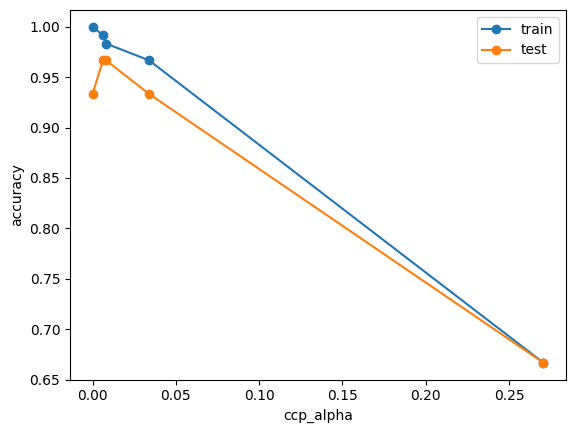

In [39]:
path = model.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]   # drop the last one: it prunes the tree down to a single root node
print("candidate alphas:", alphas.round(4))
print()

results = []
for a in alphas:
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=42).fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    results.append((a, tr, te, m.get_n_leaves()))
    print(f"ccp_alpha={a:<8.4f} train={tr:.3f} test={te:.3f} leaves={m.get_n_leaves()}")

a_list, tr_list, te_list, leaf_list = zip(*results)
plt.plot(a_list, tr_list, marker='o', label='train')
plt.plot(a_list, te_list, marker='o', label='test')
plt.xlabel('ccp_alpha')
plt.ylabel('accuracy')
plt.legend()
plt.show()

Only five alphas exist for this tree, because there are only five distinct shapes it can be pruned into. And the middle of that list is the best result in the entire notebook: `ccp_alpha=0.0081` gives `0.967` test accuracy with **4 leaves** — half the size of the unpruned tree and more accurate than it. `ccp_alpha=0.0063` matches that accuracy with 6 leaves. At the far end, `0.2707` prunes away everything but the root split and drops to the stump's `0.667`.

The appeal of `ccp_alpha` over `max_depth` is that the candidate list is computed *from the data*, so instead of guessing a grid of depths you sweep the handful of alphas the tree itself says are meaningful. The usual production recipe is exactly the loop above, but with cross-validation in place of a single test split.

## 10. Hyperparameters — `max_leaf_nodes` and `min_impurity_decrease`

Two more ways of saying "stop growing", each from a different angle:

- **`max_leaf_nodes`** — caps the tree's total number of leaves. When set, the tree is grown **best-first** (the most impurity-reducing split anywhere in the tree goes next) instead of depth-first, so the budget gets spent where it helps most.
- **`min_impurity_decrease`** — a split is only accepted if it reduces impurity by at least this much. A direct "is this split worth it?" test, rather than an indirect size limit.

In [40]:
print("--- max_leaf_nodes ---")
for v in [2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_leaf_nodes=v, random_state=42).fit(X_train, y_train)
    print(f"max_leaf_nodes={str(v):<5} test={accuracy_score(y_test, m.predict(X_test)):.3f} "
          f"leaves={m.get_n_leaves()} depth={m.get_depth()}")

print()
print("--- min_impurity_decrease ---")
for v in [0.0, 0.01, 0.05, 0.1, 0.3]:
    m = DecisionTreeClassifier(min_impurity_decrease=v, random_state=42).fit(X_train, y_train)
    print(f"min_impurity_decrease={v:<5} test={accuracy_score(y_test, m.predict(X_test)):.3f} "
          f"leaves={m.get_n_leaves()} depth={m.get_depth()}")

--- max_leaf_nodes ---
max_leaf_nodes=2     test=0.667 leaves=2 depth=1
max_leaf_nodes=3     test=0.933 leaves=3 depth=2
max_leaf_nodes=5     test=0.967 leaves=5 depth=3
max_leaf_nodes=10    test=0.933 leaves=8 depth=5
max_leaf_nodes=None  test=0.933 leaves=8 depth=5

--- min_impurity_decrease ---
min_impurity_decrease=0.0   test=0.933 leaves=8 depth=5
min_impurity_decrease=0.01  test=0.967 leaves=4 depth=3


min_impurity_decrease=0.05  test=0.933 leaves=3 depth=2
min_impurity_decrease=0.1   test=0.933 leaves=3 depth=2
min_impurity_decrease=0.3   test=0.667 leaves=2 depth=1


Both reach `0.967` again — `max_leaf_nodes=5` and `min_impurity_decrease=0.01` (4 leaves). At this point five different hyperparameters (`max_depth`, `min_samples_split`, `min_samples_leaf`, `ccp_alpha`, and these two) have each found the same answer, which is the real lesson of Sections 5-10: **they are all the same knob wearing different clothes — "how big is this tree allowed to get?"** Tuning all of them at once in a giant grid is mostly wasted compute. Pick one or two and search them properly.

## 11. `monotonic_cst` (Brief)

The one remaining hyperparameter, and a fairly recent addition (scikit-learn 1.4+). It forces the predicted probability to be **monotonically increasing (`1`), decreasing (`-1`), or unconstrained (`0`)** with respect to each feature.

It exists for domains where a direction is known in advance and must be respected regardless of what the data happens to show — "a higher income must never *lower* a credit score", for example. It takes an array with one entry per feature, and is only supported for binary classification. Not needed for Iris's 3 classes.

## 12. Quick Reference — Which Hyperparameter Matters Most?

| Priority | Hyperparameter | When it matters |
|---|---|---|
| 🥇 1st | **`max_depth`** | Always — the primary overfitting control. |
| 🥈 2nd | **`min_samples_leaf`** / `min_samples_split` | Always, especially on noisy data — a gentler alternative to a hard depth cap. |
| 🥉 3rd | **`ccp_alpha`** | When you want the size chosen *for* you by the data rather than guessed. |
| 4th | **`class_weight`** | Imbalanced classes — as Section 8 showed, essential there, irrelevant otherwise. |
| 5th | **`max_features`**, `splitter` | Mainly for adding variety inside an ensemble; single trees rarely need them. |
| Rarely | `criterion`, `max_leaf_nodes`, `min_impurity_decrease`, `min_weight_fraction_leaf`, `monotonic_cst` | Fine-tuning, or specific domain constraints. |
| Not a knob | `random_state` | Reproducibility only — but *always* set it. |

**One-line summary:** control the tree's size first (`max_depth` and `min_samples_leaf`, or let `ccp_alpha` do it), fix `class_weight` if the classes are imbalanced, and leave the rest alone until you have a specific reason.

## 13. The Complete List (Every Hyperparameter, Pulled From the Installed Library)

`DecisionTreeClassifier` has considerably more knobs than `KNeighborsClassifier`'s eight — Sections 4-11 above covered every one of them. Let's confirm that directly from the installed library with `inspect.signature`, so nothing is left out:

In [41]:
import inspect
import sklearn

print("scikit-learn version:", sklearn.__version__)
print()
sig = inspect.signature(DecisionTreeClassifier.__init__)
for name, param in sig.parameters.items():
    if name == 'self':
        continue
    print(f"{name:<26} default = {param.default!r}")

scikit-learn version:

 1.8.0

criterion                  default = 'gini'
splitter                   default = 'best'
max_depth                  default = None
min_samples_split          default = 2
min_samples_leaf           default = 1
min_weight_fraction_leaf   default = 0.0
max_features               default = None
random_state               default = None
max_leaf_nodes             default = None
min_impurity_decrease      default = 0.0
class_weight               default = None
ccp_alpha                  default = 0.0
monotonic_cst              default = None


Thirteen in total: `criterion`, `splitter`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `min_weight_fraction_leaf`, `max_features`, `random_state`, `max_leaf_nodes`, `min_impurity_decrease`, `class_weight`, `ccp_alpha`, `monotonic_cst` — all thirteen covered above, and none of them deprecated in this installed version. As always, defaults can shift between scikit-learn releases, so this cell's live output reflects whatever is installed when it was last run.

(`DecisionTreeRegressor` is the same list, with `criterion` swapped for the regression options — `'squared_error'`, `'friedman_mse'`, `'absolute_error'`, `'poisson'` — and no `class_weight`.)

---
# Summary & Key Takeaways

1. **The model**: a Decision Tree asks a sequence of "is this feature above or below a threshold?" questions and reads off the class at the leaf. No distances, no weights, no scaling — just splits.

2. **The pipeline** (Part 1): load Iris (3 classes), split with `stratify=y`, fit `DecisionTreeClassifier` **without any scaler**, then evaluate with accuracy, a confusion matrix, and a classification report — `0.933`, with both errors on the genuinely overlapping versicolor/virginica boundary.

3. **You can read the model** (Part 1, Sections 5-6): `plot_tree` and `export_text` print the fitted model in full, and `feature_importances_` shows the petal measurements carrying ~96% of the decision. Nothing else in this repo's notebooks offers that.

4. **Parameters vs. hyperparameters** (Part 2, Section 3): a tree sits between the other two notebooks — KNN's `.fit()` learns *nothing*, Logistic Regression's learns a fixed vector of weights, and a tree learns a **structure** that grows with the data. `model.tree_` is the learned parameter.

5. **Unpruned trees overfit, always**: the default `max_depth=None` grows until every leaf is pure — a perfect `1.000` on train and `0.933` on test. Every good result in this notebook came from making the tree *smaller*.

6. **All the size knobs are the same knob**: `max_depth=3`, `min_samples_leaf=3`, `min_samples_split=5`, `ccp_alpha=0.0081`, `max_leaf_nodes=5` and `min_impurity_decrease=0.01` each independently found ~`0.967` with 4-5 leaves. Tune one or two of them well rather than all six badly — and `ccp_alpha` has the advantage of computing its own candidate list from the data.

7. **Accuracy hides imbalance** (Section 8): on a 95/5 split, the default tree scored `0.963` accuracy while missing over half the minority class. `class_weight='balanced'` raised minority recall from `0.472` to `0.774` at the cost of precision — the right trade depends on the domain, but the *decision* has to be made deliberately.

8. **Trees are unstable, and that's the point of forests** (Section 7): the same configuration varies by a couple of percent across random seeds. `max_features='sqrt'` and `splitter='random'` make a single tree worse on purpose — Random Forest and Extra Trees then average hundreds of those weakened, decorrelated trees into something stronger than any single tree here.